In [ ]:
!pip install transformers torch scikit-learn pandas numpy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/DeepSignal/train.csv")
val_df = pd.read_csv("/content/drive/MyDrive/DeepSignal/val.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

train_df.head()

Train shape: (9840, 4)
Validation shape: (1230, 4)


,text,depression,toxicity,manipulation
0,Thank you. I'll definately be sure to pick up ...,0,0,0
1,"Your mental health. You might think its fine, ...",0,0,0
2,"That argument makes no sense, WM. Society move...",0,0,0
3,tHiS iS wHY TruMP wiLL wiN!!!!!1!1,0,0,0
4,"Nice story, Mike. Thanks for researching it.",0,0,0


In [ ]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# Test tokenization
sample_text = train_df["text"].iloc[0]

encoded = tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

encoded

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

{'input_ids': tensor([[  101,  4067,  2017,  1012,  1045,  1005,  2222, 13366, 14776,  2135,
          2022,  2469,  2000,  4060,  2039,  2008,  2338,  8811,  1012,   102,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,  

In [ ]:
import torch
from torch.utils.data import Dataset

class DeepSignalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.texts = dataframe["text"].values
        self.labels = dataframe[["depression", "toxicity", "manipulation"]].values
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        labels = torch.tensor(self.labels[idx], dtype=torch.float)

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels
        }

In [ ]:
from torch.utils.data import DataLoader

# Create dataset objects
train_dataset = DeepSignalDataset(train_df, tokenizer)
val_dataset = DeepSignalDataset(val_df, tokenizer)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 615
Validation batches: 77


In [ ]:
import torch.nn as nn
from transformers import DistilBertModel

class DeepSignalModel(nn.Module):
    def __init__(self):
        super(DeepSignalModel, self).__init__()

        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(768, 3)  # 3 labels

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled_output = outputs.last_hidden_state[:, 0]  # CLS token
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        return logits

In [ ]:
# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepSignalModel()
model.to(device)

# Multi-label loss
criterion = nn.BCEWithLogitsLoss()

# Optimizer
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

print("Model ready on:", device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready on: cuda


In [ ]:
num_epochs = 1

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    print(f"Epoch {epoch+1} Train Loss: {train_loss:.4f}")

NameError: name 'train_epoch' is not defined

In [ ]:
from tqdm import tqdm

def train_epoch(model, data_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for batch in tqdm(data_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)

In [ ]:
num_epochs = 1

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    print(f"Epoch {epoch+1} Train Loss: {train_loss:.4f}")

100%|██████████| 615/615 [02:01<00:00,  5.04it/s]

Epoch 1 Train Loss: 0.0854


In [ ]:
def eval_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

    return total_loss / len(data_loader)

In [ ]:
val_loss = eval_model(model, val_loader, criterion, device)
print(f"Validation Loss: {val_loss:.4f}")

Validation Loss: 0.0631


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

all_labels = np.vstack(all_labels)
all_preds = np.vstack(all_preds)

print(classification_report(
    all_labels,
    all_preds,
    target_names=["Depression", "Toxicity", "Manipulation"]
))

              precision    recall  f1-score   support

  Depression       0.67      0.35      0.46        40
    Toxicity       0.00      0.00      0.00        37
Manipulation       1.00      0.97      0.98        31

   micro avg       0.86      0.41      0.55       108
   macro avg       0.56      0.44      0.48       108
weighted avg       0.53      0.41      0.45       108
 samples avg       0.04      0.04      0.04       108



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
import numpy as np

# Calculate positive counts
label_sums = train_df[["depression", "toxicity", "manipulation"]].sum()

# Total samples
total_samples = len(train_df)

# Compute positive weight
pos_weights = total_samples / (3 * label_sums)

pos_weights = torch.tensor(pos_weights.values, dtype=torch.float).to(device)

pos_weights

tensor([10.0923, 12.4242, 13.7238], device='cuda:0')

In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

In [ ]:
num_epochs = 2

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = eval_model(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print("-" * 30)

100%|██████████| 615/615 [02:05<00:00,  4.88it/s]


Epoch 1
Train Loss: 0.2274
Validation Loss: 0.3061
------------------------------


100%|██████████| 615/615 [02:04<00:00,  4.93it/s]


In [ ]:
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

all_labels = np.vstack(all_labels)
all_preds = np.vstack(all_preds)

print(classification_report(
    all_labels,
    all_preds,
    target_names=["Depression", "Toxicity", "Manipulation"]
))

              precision    recall  f1-score   support

  Depression       0.44      0.70      0.54        40
    Toxicity       0.47      0.57      0.51        37
Manipulation       1.00      0.97      0.98        31

   micro avg       0.57      0.73      0.64       108
   macro avg       0.63      0.75      0.68       108
weighted avg       0.61      0.73      0.66       108
 samples avg       0.06      0.06      0.06       108



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs)

        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.vstack(all_labels)
all_probs = np.vstack(all_probs)

all_probs[:5]

array([[0.00276878, 0.00371603, 0.00176858],
       [0.00272512, 0.00186352, 0.00344953],
       [0.00194129, 0.00655066, 0.00210085],
       [0.07616391, 0.00614083, 0.00039705],
       [0.00378217, 0.00157297, 0.01142665]], dtype=float32)

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

best_thresholds = []

for i in range(3):
    best_f1 = 0
    best_thresh = 0.5

    for thresh in np.arange(0.05, 0.5, 0.05):
        preds = (all_probs[:, i] > thresh).astype(int)
        f1 = f1_score(all_labels[:, i], preds)

        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    best_thresholds.append(best_thresh)
    print(f"Label {i} Best Threshold: {best_thresh}, F1: {best_f1:.4f}")

best_thresholds

Label 0 Best Threshold: 0.45, F1: 0.5234
Label 1 Best Threshold: 0.2, F1: 0.5684
Label 2 Best Threshold: 0.1, F1: 0.9836


[np.float64(0.45), np.float64(0.2), np.float64(0.1)]

In [ ]:
thresholds = [0.45, 0.2, 0.1]

optimized_preds = np.zeros_like(all_probs)

for i in range(3):
    optimized_preds[:, i] = (all_probs[:, i] > thresholds[i]).astype(int)

print(classification_report(
    all_labels,
    optimized_preds,
    target_names=["Depression", "Toxicity", "Manipulation"]
))

              precision    recall  f1-score   support

  Depression       0.42      0.70      0.52        40
    Toxicity       0.47      0.73      0.57        37
Manipulation       1.00      0.97      0.98        31

   micro avg       0.55      0.79      0.65       108
   macro avg       0.63      0.80      0.69       108
weighted avg       0.60      0.79      0.67       108
 samples avg       0.07      0.07      0.07       108



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def compute_risk_score(probs):
    # Weighted composite
    return (
        0.5 * probs[0] +
        0.3 * probs[1] +
        0.2 * probs[2]
    )

# Example using first validation sample
sample_probs = all_probs[0]
risk_score = compute_risk_score(sample_probs)

risk_score


np.float32(0.0028529153)

In [ ]:
def categorize_risk(score):
    if score < 0.2:
        return "Safe"
    elif score < 0.4:
        return "Monitor"
    elif score < 0.7:
        return "Moderate Risk"
    else:
        return "Critical Risk"

# Test it
print("Risk Score:", risk_score)
print("Category:", categorize_risk(risk_score))

Risk Score: 0.0028529153
Category: Safe


In [ ]:
# Find a validation example with highest composite risk
risk_scores = np.array([compute_risk_score(p) for p in all_probs])

max_index = np.argmax(risk_scores)

print("Highest Risk Score:", risk_scores[max_index])
print("Category:", categorize_risk(risk_scores[max_index]))
print("\nText:\n", val_df.iloc[max_index]["text"])
print("\nTrue Labels:", all_labels[max_index])

Highest Risk Score: 0.5081607
Category: Moderate Risk

Text:
 I am so sorry! I hope you are okay!

True Labels: [1. 0. 0.]


In [ ]:
def predict_text(text):
    model.eval()

    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs).cpu().numpy()[0]

    # Apply tuned thresholds
    thresholds = [0.45, 0.2, 0.1]
    preds = (probs > thresholds).astype(int)

    risk_score = compute_risk_score(probs)
    risk_category = categorize_risk(risk_score)

    return {
        "probabilities": {
            "depression": float(probs[0]),
            "toxicity": float(probs[1]),
            "manipulation": float(probs[2])
        },
        "predictions": {
            "depression": int(preds[0]),
            "toxicity": int(preds[1]),
            "manipulation": int(preds[2])
        },
        "risk_score": float(risk_score),
        "risk_category": risk_category
    }

In [ ]:
# Test 1 — Depression-style text
print(predict_text("I feel empty and hopeless. I don't see any reason to continue."))

# Test 2 — Toxic text
print(predict_text("You are absolutely disgusting and stupid."))

# Test 3 — Manipulative text
print(predict_text("If you loved me, you would do this for me."))

# Test 4 — Normal text
print(predict_text("The weather is nice today and I went for a walk."))

{'probabilities': {'depression': 0.9910091161727905, 'toxicity': 0.01990153267979622, 'manipulation': 0.01995408907532692}, 'predictions': {'depression': 1, 'toxicity': 0, 'manipulation': 0}, 'risk_score': 0.5054658651351929, 'risk_category': 'Moderate Risk'}
{'probabilities': {'depression': 0.09614957123994827, 'toxicity': 0.4725174605846405, 'manipulation': 0.006762889679521322}, 'predictions': {'depression': 0, 'toxicity': 1, 'manipulation': 0}, 'risk_score': 0.19118259847164154, 'risk_category': 'Safe'}
{'probabilities': {'depression': 0.006996987387537956, 'toxicity': 0.017022697255015373, 'manipulation': 0.9993484616279602}, 'predictions': {'depression': 0, 'toxicity': 0, 'manipulation': 1}, 'risk_score': 0.2084749937057495, 'risk_category': 'Monitor'}
{'probabilities': {'depression': 0.008549499325454235, 'toxicity': 0.0032441297080367804, 'manipulation': 0.002714210655540228}, 'predictions': {'depression': 0, 'toxicity': 0, 'manipulation': 0}, 'risk_score': 0.005790831055492163

In [ ]:
# Create save directory
import os

save_path = "/content/drive/MyDrive/DeepSignal/model"
os.makedirs(save_path, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), f"{save_path}/deepsignal_model.pt")

# Save tokenizer
tokenizer.save_pretrained(save_path)

print("Model and tokenizer saved successfully.")

Model and tokenizer saved successfully.


In [ ]:
def categorize_risk_advanced(probs):
    depression, toxicity, manipulation = probs

    # Rule-based overrides
    if depression > 0.9:
        return "Critical Risk"

    if toxicity > 0.8:
        return "High Toxicity Risk"

    if manipulation > 0.9:
        return "High Manipulation Risk"

    # Composite score fallback
    score = compute_risk_score(probs)

    if score < 0.2:
        return "Safe"
    elif score < 0.4:
        return "Monitor"
    elif score < 0.7:
        return "Moderate Risk"
    else:
        return "Critical Risk"

In [ ]:
def predict_text(text):
    model.eval()

    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs).cpu().numpy()[0]

    # Apply tuned thresholds
    thresholds = [0.45, 0.2, 0.1]
    preds = (probs > thresholds).astype(int)

    risk_score = compute_risk_score(probs)
    risk_category = categorize_risk_advanced(probs)

    return {
        "probabilities": {
            "depression": float(probs[0]),
            "toxicity": float(probs[1]),
            "manipulation": float(probs[2])
        },
        "predictions": {
            "depression": int(preds[0]),
            "toxicity": int(preds[1]),
            "manipulation": int(preds[2])
        },
        "risk_score": float(risk_score),
        "risk_category": risk_category
    }

In [ ]:
print(predict_text("I feel empty and hopeless. I don't see any reason to continue."))

print(predict_text("You are absolutely disgusting and stupid."))

print(predict_text("If you loved me, you would do this for me."))

print(predict_text("The weather is nice today and I went for a walk."))

{'probabilities': {'depression': 0.9910091161727905, 'toxicity': 0.01990153267979622, 'manipulation': 0.01995408907532692}, 'predictions': {'depression': 1, 'toxicity': 0, 'manipulation': 0}, 'risk_score': 0.5054658651351929, 'risk_category': 'Critical Risk'}
{'probabilities': {'depression': 0.09614957123994827, 'toxicity': 0.4725174605846405, 'manipulation': 0.006762889679521322}, 'predictions': {'depression': 0, 'toxicity': 1, 'manipulation': 0}, 'risk_score': 0.19118259847164154, 'risk_category': 'Safe'}
{'probabilities': {'depression': 0.006996987387537956, 'toxicity': 0.017022697255015373, 'manipulation': 0.9993484616279602}, 'predictions': {'depression': 0, 'toxicity': 0, 'manipulation': 1}, 'risk_score': 0.2084749937057495, 'risk_category': 'High Manipulation Risk'}
{'probabilities': {'depression': 0.008549499325454235, 'toxicity': 0.0032441297080367804, 'manipulation': 0.002714210655540228}, 'predictions': {'depression': 0, 'toxicity': 0, 'manipulation': 0}, 'risk_score': 0.005

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 128.7 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.1
    Uninstalling cachetools-7.0.1:
      Successfully uninstalled cachetools-7.0.1


In [ ]:
%%writefile app.py

import streamlit as st
import torch
import torch.nn as nn
from transformers import DistilBertModel, DistilBertTokenizer
import numpy as np

# ---------------------------
# Load Model Architecture
# ---------------------------
class DeepSignalModel(nn.Module):
    def __init__(self):
        super(DeepSignalModel, self).__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(768, 3)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        pooled_output = self.dropout(pooled_output)
        return self.classifier(pooled_output)


# ---------------------------
# Load Saved Model
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepSignalModel()
model.load_state_dict(torch.load("/content/drive/MyDrive/DeepSignal/model/deepsignal_model.pt", map_location=device))
model.to(device)
model.eval()

tokenizer = DistilBertTokenizer.from_pretrained("/content/drive/MyDrive/DeepSignal/model")


# ---------------------------
# Risk Functions
# ---------------------------
def compute_risk_score(probs):
    return (
        0.5 * probs[0] +
        0.3 * probs[1] +
        0.2 * probs[2]
    )

def categorize_risk_advanced(probs):
    depression, toxicity, manipulation = probs

    if depression > 0.9:
        return "Critical Risk"

    if toxicity > 0.8:
        return "High Toxicity Risk"

    if manipulation > 0.9:
        return "High Manipulation Risk"

    score = compute_risk_score(probs)

    if score < 0.2:
        return "Safe"
    elif score < 0.4:
        return "Monitor"
    elif score < 0.7:
        return "Moderate Risk"
    else:
        return "Critical Risk"


# ---------------------------
# Prediction Function
# ---------------------------
def predict_text(text):
    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs).cpu().numpy()[0]

    thresholds = [0.45, 0.2, 0.1]
    preds = (probs > thresholds).astype(int)

    risk_score = compute_risk_score(probs)
    risk_category = categorize_risk_advanced(probs)

    return probs, preds, risk_score, risk_category


# ---------------------------
# Streamlit UI
# ---------------------------
st.set_page_config(page_title="DeepSignal AI Safety Engine", layout="centered")

st.title("🧠 DeepSignal AI Safety Intelligence")
st.markdown("Multi-Label Mental Health, Toxicity & Manipulation Detection")

user_input = st.text_area("Enter text to analyze:", height=150)

if st.button("Analyze"):
    if user_input.strip() == "":
        st.warning("Please enter some text.")
    else:
        probs, preds, risk_score, risk_category = predict_text(user_input)

        st.subheader("Prediction Results")

        st.write("### Probabilities")
        st.write({
            "Depression": float(probs[0]),
            "Toxicity": float(probs[1]),
            "Manipulation": float(probs[2])
        })

        st.write("### Risk Score")
        st.write(float(risk_score))

        st.write("### Risk Category")
        st.success(risk_category)

Writing app.py


In [ ]:
from pyngrok import ngrok
import os

# Kill any previous streamlit process
!pkill streamlit

# Start streamlit in background
!streamlit run app.py &>/dev/null &

# Open public URL
public_url = ngrok.connect(port="8501")
print("🚀 Your App is Live at:")
print(public_url)

ERROR:pyngrok.process.ngrok:t=2026-02-22T18:45:06+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-02-22T18:45:06+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-02-22T18:45:06+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3A2M486WlXVKHJYW5d8XIk9eCwY_44td9WoZc6thKyqw7Kqyw")

In [ ]:
# Kill any previous streamlit processes
!pkill streamlit

# Start Streamlit in background
!streamlit run app.py &>/dev/null &

from pyngrok import ngrok

# Open public tunnel
public_url = ngrok.connect(8501)
print("🚀 Your DeepSignal App is Live at:")
print(public_url)

🚀 Your DeepSignal App is Live at:
NgrokTunnel: "https://kera-curlier-quincy.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
from sklearn.metrics import roc_auc_score

roc_scores = {}

for i, label in enumerate(["Depression", "Toxicity", "Manipulation"]):
    roc = roc_auc_score(all_labels[:, i], all_probs[:, i])
    roc_scores[label] = roc

roc_scores

{'Depression': np.float64(0.9383193277310924),
 'Toxicity': np.float64(0.9498198953354026),
 'Manipulation': np.float64(0.9910947294788668)}

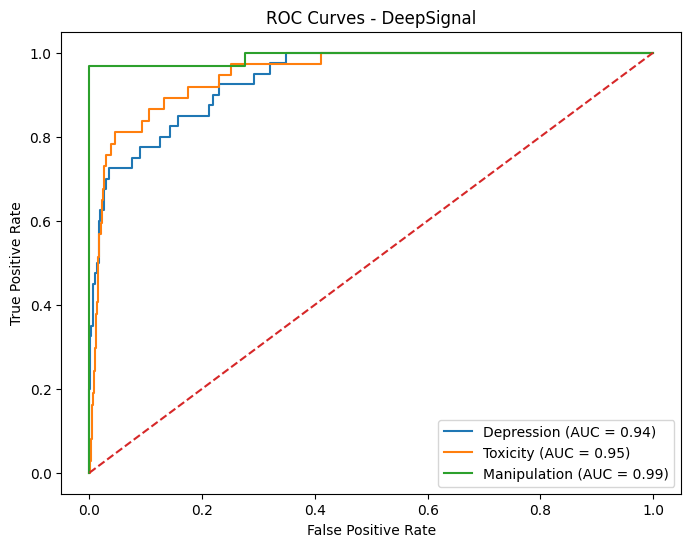

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for i, label in enumerate(["Depression", "Toxicity", "Manipulation"]):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_scores[label]:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - DeepSignal")
plt.legend()
plt.show()

In [ ]:
!cp app.py /content/drive/MyDrive/DeepSignal/app.py

In [43]:
%%writefile requirements.txt
torch
transformers
streamlit
scikit-learn
numpy
matplotlib
tqdm

Writing requirements.txt


In [44]:
!mv requirements.txt /content/drive/MyDrive/DeepSignal/requirements.txt